Ajuste o modelo para que obtenha uma redução do loss e um aumento da accuracy

Dataset: https://www.kaggle.com/datasets/gokulprasantht/nutrition-dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import userdata
import os

os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

In [3]:
!pip install -q kaggle

In [4]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/ 2>/dev/null # This line is only needed if you manually uploaded the file
!chmod 600 ~/.kaggle/kaggle.json 2>/dev/null

In [5]:
!kaggle datasets download gokulprasantht/nutrition-dataset


Dataset URL: https://www.kaggle.com/datasets/gokulprasantht/nutrition-dataset
License(s): unknown
100% 3.08M/3.08M [00:00<00:00, 4.45MB/s]



In [6]:
from google.colab import drive

drive.mount('/content/drive',force_remount=True)


Mounted at /content/drive


In [7]:
import zipfile
import io
zip_file_name = '/content/nutrition-dataset.zip' # Replace with the actual zip file name
with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall('/content/drive/MyDrive/Datasets/nutrition/') # Extract to the content directory

In [8]:
data = pd.read_excel("/content/drive/MyDrive/Datasets/nutrition/nutrition.xlsx", index_col=None)


In [9]:
data = data.iloc[:,1:]
data

,name,serving_size,calories,total_fat,saturated_fat,cholesterol,sodium,choline,folate,folic_acid,...,fat,saturated_fatty_acids,monounsaturated_fatty_acids,polyunsaturated_fatty_acids,fatty_acids_total_trans,alcohol,ash,caffeine,theobromine,water
0,Cornstarch,100 g,381,0.1g,NaN,0,9.00 mg,0.4 mg,0.00 mcg,0.00 mcg,...,0.05 g,0.009 g,0.016 g,0.025 g,0.00 mg,0.0 g,0.09 g,0.00 mg,0.00 mg,8.32 g
1,"Nuts, pecans",100 g,691,72g,6.2g,0,0.00 mg,40.5 mg,22.00 mcg,0.00 mcg,...,71.97 g,6.180 g,40.801 g,21.614 g,0.00 mg,0.0 g,1.49 g,0.00 mg,0.00 mg,3.52 g
2,"Eggplant, raw",100 g,25,0.2g,NaN,0,2.00 mg,6.9 mg,22.00 mcg,0.00 mcg,...,0.18 g,0.034 g,0.016 g,0.076 g,0.00 mg,0.0 g,0.66 g,0.00 mg,0.00 mg,92.30 g
3,"Teff, uncooked",100 g,367,2.4g,0.4g,0,12.00 mg,13.1 mg,0,0,...,2.38 g,0.449 g,0.589 g,1.071 g,0,0,2.37 g,0,0,8.82 g
4,"Sherbet, orange",100 g,144,2g,1.2g,1mg,46.00 mg,7.7 mg,4.00 mcg,0.00 mcg,...,2.00 g,1.160 g,0.530 g,0.080 g,1.00 mg,0.0 g,0.40 g,0.00 mg,0.00 mg,66.10 g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8784,"Beef, raw, all grades, trimmed to 0"" fat, sepa...",100 g,125,3.5g,1.4g,62mg,54.00 mg,64.5 mg,4.00 mcg,0.00 mcg,...,3.50 g,1.353 g,1.554 g,0.244 g,62.00 mg,0.0 g,1.11 g,0.00 mg,0.00 mg,72.51 g
8785,"Lamb, cooked, separable lean only, composite o...",100 g,206,8.9g,3.9g,109mg,50.00 mg,0,0.00 mcg,0.00 mcg,...,8.86 g,3.860 g,3.480 g,0.520 g,109.00 mg,0,1.60 g,0,0,59.95 g
8786,"Lamb, raw, separable lean and fat, composite o...",100 g,277,23g,12g,78mg,39.00 mg,0,1.00 mcg,0.00 mcg,...,22.74 g,11.570 g,8.720 g,0.980 g,78.00 mg,0,0.92 g,0,0,59.80 g
8787,"Beef, raw, all grades, trimmed to 0"" fat, sepa...",100 g,121,3g,1.1g,60mg,53.00 mg,64.2 mg,4.00 mcg,0.00 mcg,...,3.04 g,1.086 g,1.266 g,0.233 g,60.00 mg,0.0 g,1.10 g,0.00 mg,0.00 mg,73.43 g


In [10]:
data.columns

Index(['name', 'serving_size', 'calories', 'total_fat', 'saturated_fat',
       'cholesterol', 'sodium', 'choline', 'folate', 'folic_acid', 'niacin',
       'pantothenic_acid', 'riboflavin', 'thiamin', 'vitamin_a',
       'vitamin_a_rae', 'carotene_alpha', 'carotene_beta',
       'cryptoxanthin_beta', 'lutein_zeaxanthin', 'lucopene', 'vitamin_b12',
       'vitamin_b6', 'vitamin_c', 'vitamin_d', 'vitamin_e', 'tocopherol_alpha',
       'vitamin_k', 'calcium', 'copper', 'irom', 'magnesium', 'manganese',
       'phosphorous', 'potassium', 'selenium', 'zink', 'protein', 'alanine',
       'arginine', 'aspartic_acid', 'cystine', 'glutamic_acid', 'glycine',
       'histidine', 'hydroxyproline', 'isoleucine', 'leucine', 'lysine',
       'methionine', 'phenylalanine', 'proline', 'serine', 'threonine',
       'tryptophan', 'tyrosine', 'valine', 'carbohydrate', 'fiber', 'sugars',
       'fructose', 'galactose', 'glucose', 'lactose', 'maltose', 'sucrose',
       'fat', 'saturated_fatty_acids', 'mon

In [11]:
data['calories']

,calories
0,381
1,691
2,25
3,367
4,144
...,...
8784,125
8785,206
8786,277
8787,121


In [12]:
data['calories'].describe()

,calories
count,8789.000000
mean,226.283878
std,169.862001
min,0.000000
25%,91.000000
50%,191.000000
75%,337.000000
max,902.000000


In [13]:
#discretização

def filter(x):
    if x <= 91:
        return 'low'
    if (x > 91 and x <= 191):
        return 'medium'
    if (x > 191 and x <= 337):
        return 'caloric'
    elif(x > 337):
      return 'high caloric'

data['calories_cat'] = data['calories'].apply(filter)

In [14]:
data[['calories', 'calories_cat']]

,calories,calories_cat
0,381,high caloric
1,691,high caloric
2,25,low
3,367,high caloric
4,144,medium
...,...,...
8784,125,medium
8785,206,caloric
8786,277,caloric
8787,121,medium


In [15]:
data[ 'calories_cat'].value_counts()

,count
calories_cat,
low,2205
medium,2202
caloric,2197
high caloric,2185


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X, y = data[['serving_size', 'total_fat', 'saturated_fat',
       'cholesterol', 'sodium', 'choline', 'folate', 'folic_acid', 'niacin',
       'pantothenic_acid', 'riboflavin', 'thiamin', 'vitamin_a',
       'vitamin_a_rae', 'carotene_alpha', 'carotene_beta',
       'cryptoxanthin_beta', 'lutein_zeaxanthin', 'lucopene', 'vitamin_b12',
       'vitamin_b6', 'vitamin_c', 'vitamin_d', 'vitamin_e', 'tocopherol_alpha',
       'vitamin_k', 'calcium', 'copper', 'irom', 'magnesium', 'manganese',
       'phosphorous', 'potassium', 'selenium', 'zink', 'protein', 'alanine',
       'arginine', 'aspartic_acid', 'cystine', 'glutamic_acid', 'glycine',
       'histidine', 'hydroxyproline', 'isoleucine', 'leucine', 'lysine',
       'methionine', 'phenylalanine', 'proline', 'serine', 'threonine',
       'tryptophan', 'tyrosine', 'valine', 'carbohydrate', 'fiber', 'sugars',
       'fructose', 'galactose', 'glucose', 'lactose', 'maltose', 'sucrose',
       'fat', 'saturated_fatty_acids', 'monounsaturated_fatty_acids',
       'polyunsaturated_fatty_acids', 'fatty_acids_total_trans', 'alcohol',
       'ash', 'caffeine', 'theobromine', 'water']], data['calories_cat']

X = X.replace(' g','', regex=True)
X = X.replace('g','', regex=True)
X = X.replace('mg','', regex=True)
X = X.replace('m','', regex=True)
X = X.replace(' m','', regex=True)
X = X.replace('c','', regex=True)
X = X.replace(' IU','', regex=True)

# X = X.astype(float)
# y = y.astype(float)

X = np.asarray(X).astype('float32')

X = np.nan_to_num(X, nan=0)

In [18]:
pd.DataFrame(X)

,0,1,2,3,4,5,6,7,8,9,...,64,65,66,67,68,69,70,71,72,73
0,100.0,0.1,0.0,0.0,9.0,0.400000,0.0,0.0,0.000,0.000,...,0.050000,0.009,0.016000,0.025,0.0,0.0,0.09,0.0,0.0,8.320000
1,100.0,72.0,6.2,0.0,0.0,40.500000,22.0,0.0,1.167,0.863,...,71.970001,6.180,40.800999,21.614,0.0,0.0,1.49,0.0,0.0,3.520000
2,100.0,0.2,0.0,0.0,2.0,6.900000,22.0,0.0,0.649,0.281,...,0.180000,0.034,0.016000,0.076,0.0,0.0,0.66,0.0,0.0,92.300003
3,100.0,2.4,0.4,0.0,12.0,13.100000,0.0,0.0,3.363,0.942,...,2.380000,0.449,0.589000,1.071,0.0,0.0,2.37,0.0,0.0,8.820000
4,100.0,2.0,1.2,1.0,46.0,7.700000,4.0,0.0,0.063,0.224,...,2.000000,1.160,0.530000,0.080,1.0,0.0,0.40,0.0,0.0,66.099998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8784,100.0,3.5,1.4,62.0,54.0,64.500000,4.0,0.0,6.422,0.356,...,3.500000,1.353,1.554000,0.244,62.0,0.0,1.11,0.0,0.0,72.510002
8785,100.0,8.9,3.9,109.0,50.0,0.000000,0.0,0.0,7.680,0.580,...,8.860000,3.860,3.480000,0.520,109.0,0.0,1.60,0.0,0.0,59.950001
8786,100.0,23.0,12.0,78.0,39.0,0.000000,1.0,0.0,6.550,0.520,...,22.740000,11.570,8.720000,0.980,78.0,0.0,0.92,0.0,0.0,59.799999
8787,100.0,3.0,1.1,60.0,53.0,64.199997,4.0,0.0,6.720,0.355,...,3.040000,1.086,1.266000,0.233,60.0,0.0,1.10,0.0,0.0,73.430000


In [19]:
# from sklearn import preprocessing

# min_max_scaler = preprocessing.MinMaxScaler()
# x_scaled = min_max_scaler.fit_transform(X)
# X = pd.DataFrame(x_scaled)

In [20]:
X

array([[100.  ,   0.1 ,   0.  , ...,   0.  ,   0.  ,   8.32],
       [100.  ,  72.  ,   6.2 , ...,   0.  ,   0.  ,   3.52],
       [100.  ,   0.2 ,   0.  , ...,   0.  ,   0.  ,  92.3 ],
       ...,
       [100.  ,  23.  ,  12.  , ...,   0.  ,   0.  ,  59.8 ],
       [100.  ,   3.  ,   1.1 , ...,   0.  ,   0.  ,  73.43],
       [100.  ,   3.  ,   1.1 , ...,   0.  ,   0.  ,  73.43]],
      dtype=float32)

In [21]:
categories = y.astype('category').cat.categories


In [22]:
categories

Index(['caloric', 'high caloric', 'low', 'medium'], dtype='object')

In [23]:
y = y.astype('category').cat.codes
y = np.asarray(y).astype('int')
y

array([1, 1, 2, ..., 0, 3, 3])

In [24]:

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.5)

print('Shape de x_train', x_train.shape)
print('Shape de x_val', x_val.shape)
print('Shape de x_test', x_test.shape)

print('Shape de y_train', y_train.shape)
print('Shape de y_val', y_val.shape)
print('Shape de y_test', y_test.shape)


Shape de x_train (3515, 74)
Shape de x_val (3516, 74)
Shape de x_test (1758, 74)
Shape de y_train (3515,)
Shape de y_val (3516,)
Shape de y_test (1758,)


In [25]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Input, Dropout, BatchNormalization

In [26]:
model = Sequential()
model.add(Dense(32, input_shape=(74,), activation='relu'))
model.add(BatchNormalization())
#model.add(Input(16, shape=(74,), activation="relu"))
#model.add(Dense(256, activation='relu'))
# model.add(Dense(256, activation="sigmoid"))
# model.add(Dense(128, activation="relu"))
model.add(Dense(64, activation="relu"))
# model.add(BatchNormalization())
model.add(Dense(64, activation="relu"))
#model.add(Dropout(0.5))
# model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax'))
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,060 (35.39 KB)

 Trainable params: 8,996 (35.14 KB)

 Non-trainable params: 64 (256.00 B)

In [28]:
x_train.shape

(3515, 74)

In [29]:
y_train

array([0, 0, 3, ..., 3, 1, 0])

In [30]:
from tensorflow.keras.callbacks import EarlyStopping

# Definindo o Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',   # métrica monitorada
    patience=10,           # número de épocas sem melhora antes de parar
    restore_best_weights=True  # restaura os melhores pesos ao final
)

In [31]:
from keras.callbacks import ReduceLROnPlateau

lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # reduz pela metade
    patience=3,
    min_lr=1e-6
)

In [32]:
batch_size = 16
epochs = 40

history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val),
                    callbacks=[early_stopping, lr_reduction])

Epoch 1/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.4711 - loss: 1.1657 - val_accuracy: 0.6533 - val_loss: 1.0230 - learning_rate: 0.0010
Epoch 2/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6825 - loss: 0.7574 - val_accuracy: 0.8100 - val_loss: 0.6412 - learning_rate: 0.0010
Epoch 3/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7431 - loss: 0.6318 - val_accuracy: 0.8294 - val_loss: 0.5226 - learning_rate: 0.0010
Epoch 4/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7741 - loss: 0.5595 - val_accuracy: 0.8379 - val_loss: 0.5002 - learning_rate: 0.0010
Epoch 5/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8080 - loss: 0.4948 - val_accuracy: 0.8649 - val_loss: 0.4083 - learning_rate: 0.0010
Epoch 6/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8171 - loss: 0.4644 - val_accuracy: 0.8604 - val_loss: 0.3874 - learning_rate: 0.0010
Epoch 7/40
220/220 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8313 - loss: 0.4367 - 

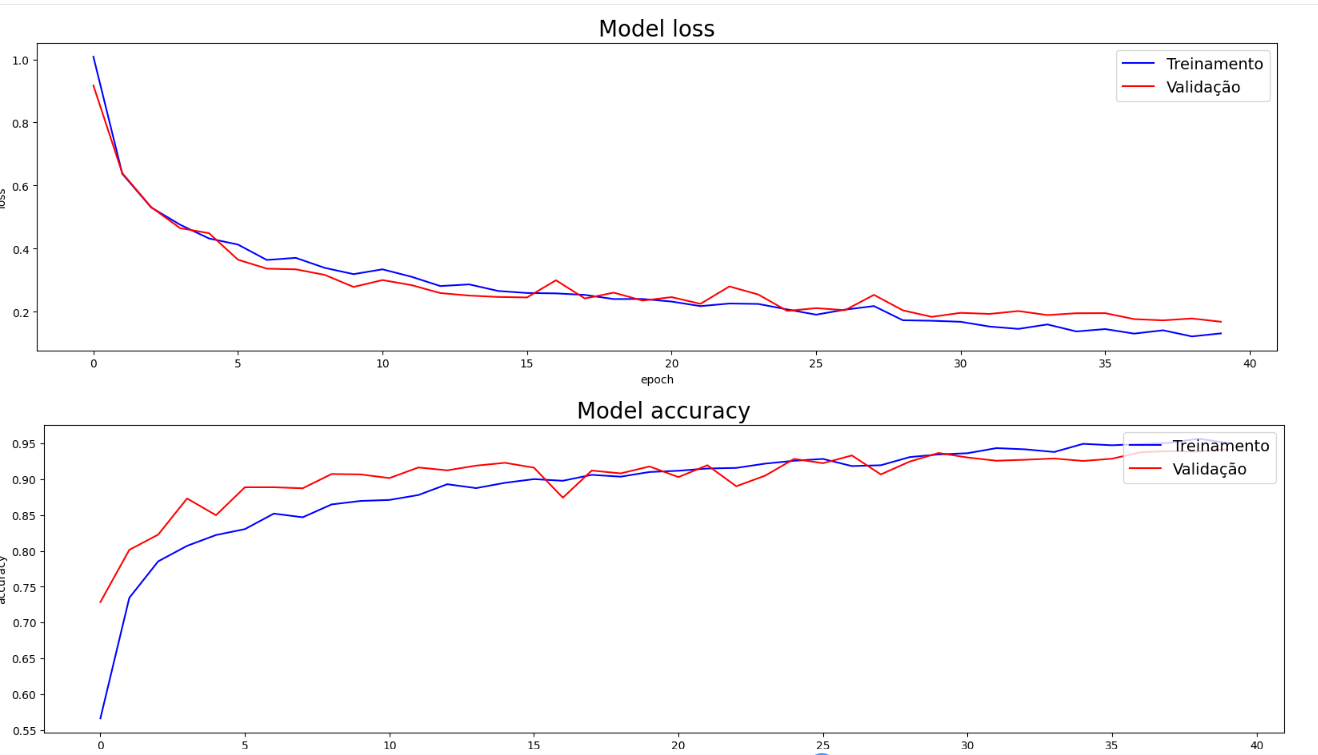

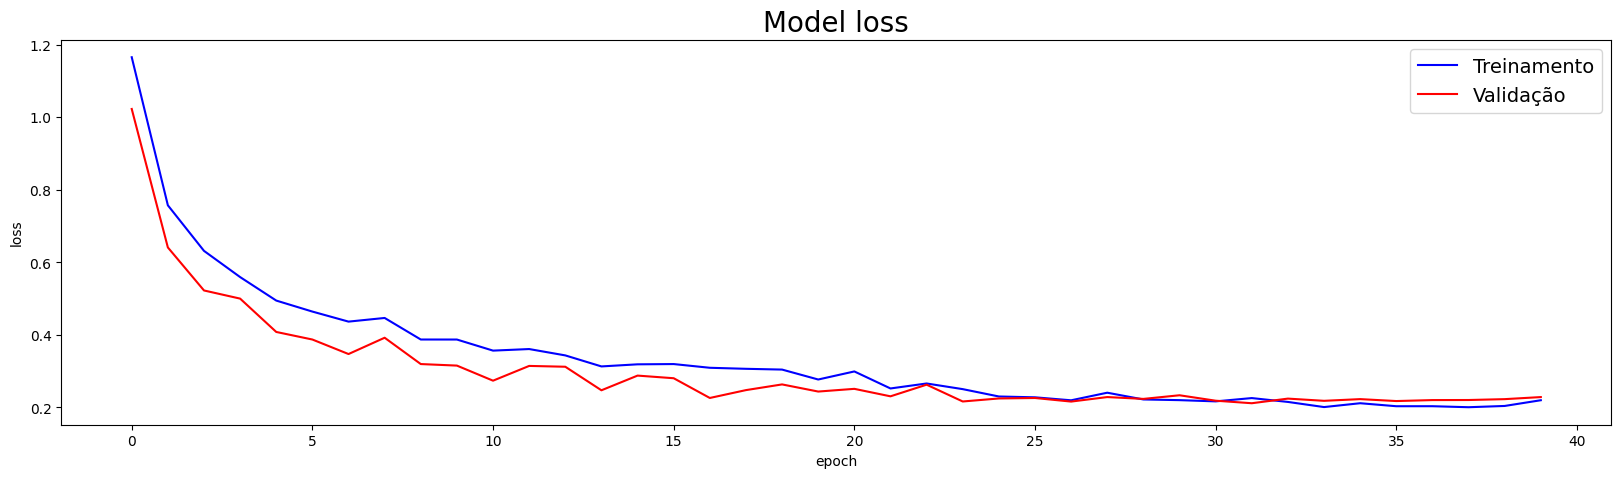

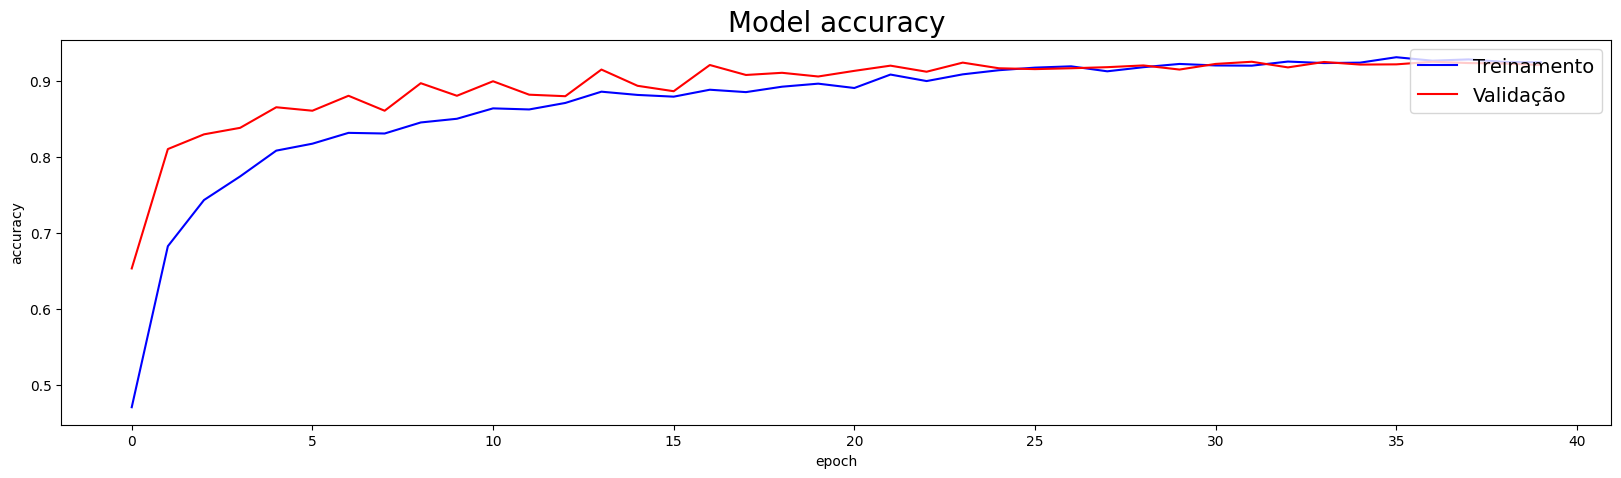

In [33]:
import matplotlib.pyplot as plt

# Plotando o historico do processo de treinamento
plt.figure(figsize=(20, 5))
plt.plot(history.history['loss'], color='blue')
plt.plot(history.history['val_loss'], color='red')
plt.title('Model loss', fontsize=20)
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Treinamento', 'Validação'], loc='upper right', fontsize=14)
plt.show()


import matplotlib.pyplot as plt

# Plotando o historico do processo de treinamento
plt.figure(figsize=(20, 5))
plt.plot(history.history['accuracy'], color='blue')
plt.plot(history.history['val_accuracy'], color='red')
plt.title('Model accuracy', fontsize=20)
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Treinamento', 'Validação'], loc='upper right', fontsize=14)
plt.show()

In [34]:
score = model.evaluate(x_test, y_test, verbose=0)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Test loss: 0.24893474578857422
Test accuracy: 0.9232081770896912


In [35]:
x_test[0].reshape(1,74)

array([[1.000e+02, 6.200e+00, 2.000e+00, 1.860e+02, 6.700e+01, 0.000e+00,
        0.000e+00, 0.000e+00, 4.229e+00, 1.827e+00, 8.380e-01, 2.290e-01,
        1.200e+01, 4.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 9.180e+00, 1.250e-01, 0.000e+00, 2.000e+00, 6.300e-01,
        6.300e-01, 0.000e+00, 5.000e+00, 6.430e-01, 4.940e+00, 2.200e+01,
        2.800e-02, 2.370e+02, 1.870e+02, 2.030e+01, 2.660e+00, 2.626e+01,
        1.306e+00, 1.768e+00, 0.000e+00, 3.440e-01, 3.669e+00, 1.123e+00,
        5.560e-01, 0.000e+00, 1.176e+00, 2.028e+00, 2.294e+00, 8.570e-01,
        1.034e+00, 8.420e-01, 8.950e-01, 1.253e+00, 2.900e-01, 9.100e-01,
        1.337e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 6.210e+00, 2.001e+00,
        1.006e+00, 9.330e-01, 1.860e+02, 0.000e+00, 9.400e-01, 0.000e+00,
        0.000e+00, 6.665e+01]], dtype=float32)

In [36]:
x_new = np.array(x_test[0].reshape(1,74))

x_new.shape

(1, 74)

In [37]:
pred = model.predict(x_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


In [38]:
pred

array([[1.8563211e-02, 2.6259153e-05, 1.2151568e-02, 9.6925896e-01]],
      dtype=float32)

In [39]:
categories[pred.argmax()]

'medium'

In [40]:
categories[y_test[0]]

'medium'

# verificar pq o uso da loss function sparse_categorical_crossentropy

# verificar como fazer a normalização com a camada da rede batchNormalization

# verificar como fazer a redução do overfit com camada dropout

# Salvar modelo

In [41]:
model.save("caloric.keras")


In [42]:
import keras

loaded_model = keras.saving.load_model("caloric.keras")

In [43]:
pred = loaded_model.predict(x_new)

categories[pred.argmax()]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


'medium'